# Production Board for a Manufacturing Shop


# Section 1: Establishing Column Format Excel

A manufacturing shoop uses an excel file in the following format for daily production meetings to coordinate labour and resources in the shop floor for the production of equipment. At the end of the day any task (shown as inividual rows) that has been partially or fully completed will be highlighted green. Any new tasks will need to be added and and old finished tasks need to be removed. This is done after copying the sheet that will de dated for tomorrow's date and any old completed task will be removed.

| SO# | Customer | Task | QTY | Item Description | WO# | Pulled Parts? | Shop Due Date | Initials | Done? |
| -------- | -------- | -------- | -------- | -------- | -------- | -------- | -------- | -------- | -------- |
| Section A ||    |
| 11111 | ABC Company | Machining | 2 | Pump, 12000 BPD, 100" Lg | 25435 | Y | 02-02-2023  | JM | Y |
| - |
|Section B||    |
| - |
| - |

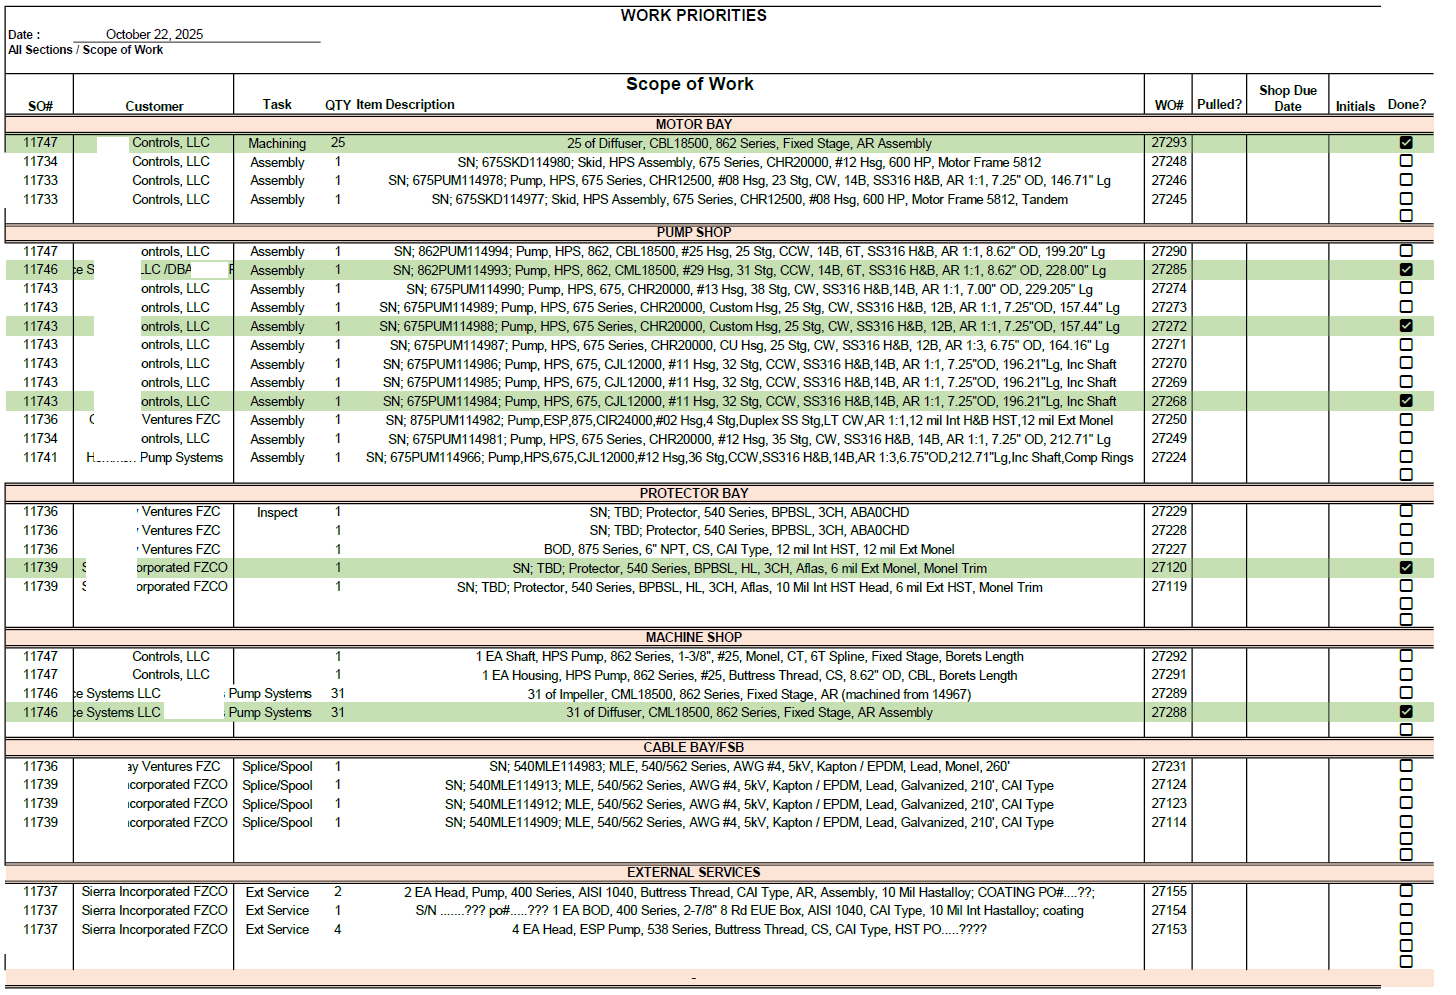

# Section 2. Establishing Column for SQL query

As we know the format of how the result of the query should be, we can quickly type this out in our SQL file, while also matching the column headings.

In [ ]:
%%sql

SELECT 
	 COALESCE(CAST(T0.OriginNum AS VARCHAR), 'MFG-Internal') AS "SalesOrder"	-- Use COALESCE to assign Internal Manufacturing Tasks with no Sales Order No. as  MFG-Internal
	,COALESCE(T1.CardName, 'MFG-Internal') AS "CustomerName"					-- Use COALESCE to assign Internal Manufacturing Tasks with no Customer Name as MFG-Internal
	,' ' AS "Task"
	,CAST(T0.PlannedQty AS INT) AS "QTY"				-- Simplify as just 'QTY'
	,T0.Comments AS "Description"     					-- The comments/remarks is mainly used as product description and quantity so heading should reflect this.
	,T0.DocNum AS "WO#"			-- Production Order Number or WO# column will be left of QTY and DESCRIPTION.
	,' ' AS "PartPulled?"		-- Empty placeholder for columns in the target spreadsheet
	,' ' AS "ShopDueDate"		-- Empty placeholder for columns in the target spreadsheet
	,' ' AS "Initials"			-- Empty placeholder for columns in the target spreadsheet
	,' ' AS "Completed",		-- Empty placeholder for columns in the target spreadsheet
	...

Taking note as well of the way the rows are grouped, we will utilise an additional column called "Area" to help sort our query results in a similar manner. We can do this by identifying the type of product by their ItemGroupCode and assigning names for it.

In [ ]:
...
-- Use CASE Expression to allow sorting of work orders by product type.
CASE 
	WHEN	T2.ItmsGrpCod LIKE '101%'
			OR T2.ItmsGrpCod LIKE '112%'
			OR T2.ItmsGrpCod LIKE '113%'
			THEN 'MachineShop'	
	WHEN T2.ItmsGrpCod LIKE '143%' THEN 'PumpBay'
	WHEN	T2.ItmsGrpCod LIKE '141%'
			OR T2.ItmsGrpCod LIKE '152%'
			OR T2.ItmsGrpCod LIKE '190%' THEN 'MotorBay'
	WHEN T2.ItmsGrpCod LIKE '142%'
			OR T2.ItmsGrpCod LIKE '144%' 
			OR T2.ItmsGrpCod LIKE '159%'
			OR T2.ItmsGrpCod LIKE '195%' THEN 'Protector'
	WHEN	T2.ItmsGrpCod LIKE '205%'
			OR T2.ItmsGrpCod LIKE '135%'
			OR T2.ItmsGrpCod LIKE '248%' THEN 'CableBay/FSB'
	END AS "Area"
...

# Section 3. Selecting the Tables to obtain the data

In SAP B1, a new item to plan for proudction requires creating a new production order. Referring to the Erpref.com, we find that the table for this on SAP is called OWOR. This table does not have the full description of the part, so we will use OITM table that we can join to obtain this. The name of the customer is also not on the OWOR Table, so we will need to join it with the Sales Order table ORDR to get it. We can also go on SAP and turn on Ctrl+Shift+I to get the column names of the field that we will use for the query.

In [ ]:
...
FROM OWOR T0  								--Main table to display must be declared* before the joins, note it appears on the left side of the ON statement*/

	LEFT JOIN ORDR T1 ON T0.OriginNum = T1.DocNum       -- We assign an alias to the tables to simplify writing out the tables shown in the above codes
	INNER JOIN OITM T2 ON T0.ItemCode = T2.ItemCode     
...

In SAP B1, we are only interested in 'Planned' or 'Released' Production Orders only as this indicates the task is a Work-in-Progress by the shop floor. This is denoted by 'P' and 'R', respectively, on the OWOR Table on the SQL database for SAP.

In [ ]:
...
WHERE 
	-- T0.[PostDate] between [%1] AND [%2] AND 			--Decision to omit a date condition as we are only interested in PLANNED and RELEASED #WO
	T0.[Status] IN ('R', 'P')							--RELEASED and PLANNED production orders only.*/

ORDER BY Area  DESC, T0.OriginNum ASC;			--Sort by the group classification first, then by descending SO#
...

# Section 4: Creating the query

We know the format and which tables to use, so now we can create our query with the information on hand by putting together all of the above.

# Section 5: Analysing the query result

We run the sql file in SSMS (SQL Server Management Studio) in our local, non-live SQL server to obtain the results.

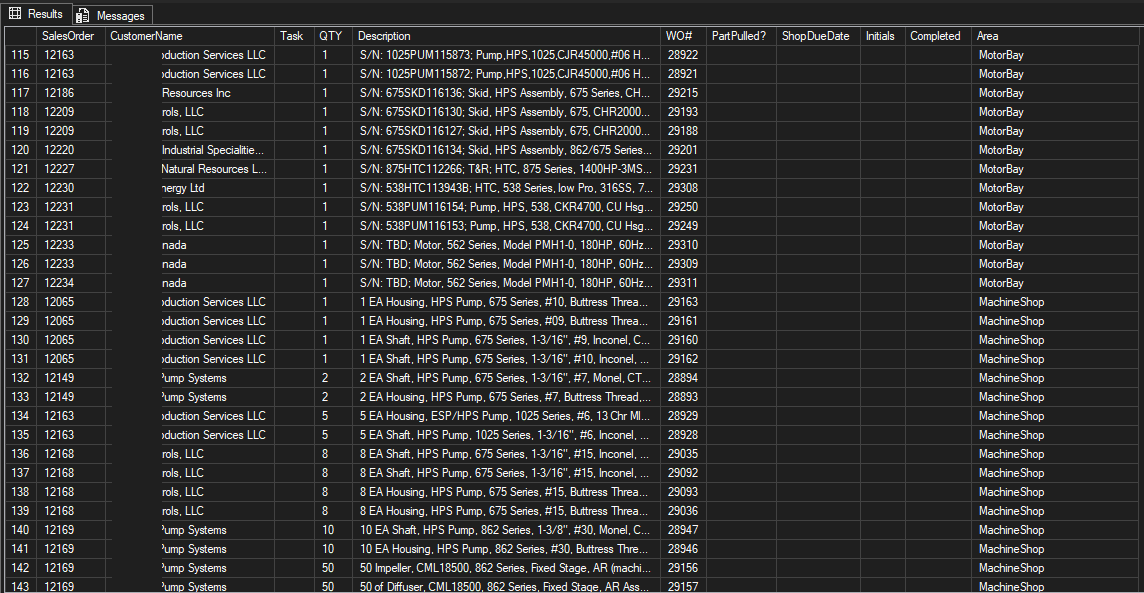

# Section 6: Merging to the working excel file 

The following PowerShell script is created to merge any new rows/entries to the working excel file.